# Fokker-Planck Equation from 1D Brownian Motion Trajectories

In the previous notebook, we visualised one realisation of the stochastic trajectory. By changing the random seed of the simulation, we sample differently from the $ \mathcal{N}(0,1)$ for the stochastic part of the Langevin Equation. We sample different realisations of the stochastic trajectories by changing the random seed of each run.   

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from zero_potential_lf import integrate_langevin_leapfrog
from complete_lf import integrate_langevin_leapfrog_with_potential
from scipy.ndimage import gaussian_filter1d

Text(0.5, 1.0, 'Stochastic Trajectories')

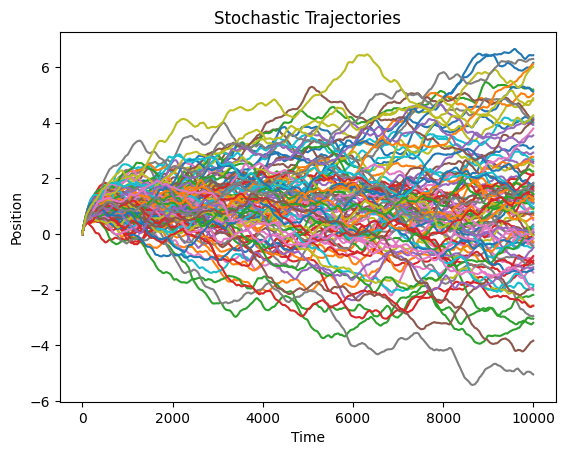

In [2]:
seeds = np.arange(1000)   # 1000 independent simulations

# Storage arrays
all_time = []
all_x = []
all_v = []
dt=0.01

for seed in seeds:
    time, x, v = integrate_langevin_leapfrog(
        x0=0.0,
        v0=1.0,
        n_steps=10000,
        dt=dt,
        g=1.0,
        m=1.0,
        D=0.1,
        seed=seed
    )

    all_time.append(time)
    all_x.append(x)
    all_v.append(v)

# Convert lists to arrays
all_time = np.array(all_time)
x_all = np.array(all_x)
v_all = np.array(all_v)

for i in range(1, 100):
    plt.plot(x_all[i])
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Stochastic Trajectories")

In the above plot, each of 1000 trajectories are visualized. It should be noted that all simulations initialize from the same starting position and velocity however, as it evolves the noise added to the system leads to very different final positions. In the plot below the spatial distribution of particles is given and it follows an exact Gaussian distribution because the noise term here is Gaussian White Noise and sum of Gaussian icrements is Gaussian. Hence, here we get a Gaussian distribution without invoking the central limit theorem which usually involves noise which are non-Gaussian but independent.

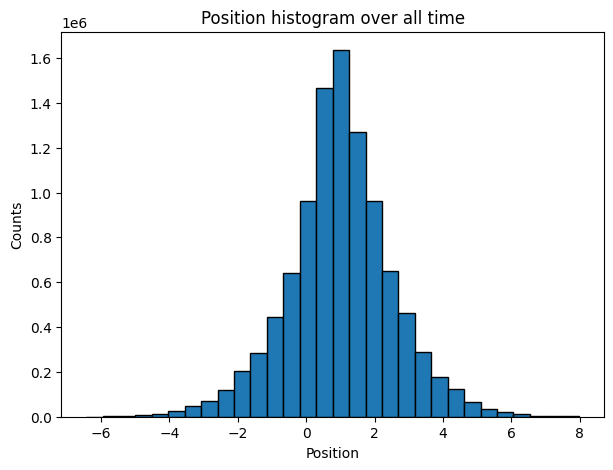

In [3]:
positions_all_time = x_all.flatten()

plt.figure(figsize=(7, 5))

plt.hist(
    positions_all_time,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Position")
plt.ylabel("Counts")
plt.title("Position histogram over all time")

plt.show()

## Fokker-Planck Equation

The Fokker-Planck equation is a partial differential equation that describes the time evolution of the probability density function. 
$$\frac{\partial P(x,t)}{\partial t} = - \frac{\partial}{\partial x} \left[ A(x) P(x,t) \right] + \frac{1}{2}\frac{\partial^{2}}{\partial x^2} \left[ B(x) P(x,t) \right] \tag{1}$$

Where $A(x)$ is the term from drift and captures the average velocity-like tendency. $B(x)$ is the diffusion term and captures the random spreading strength. These terms can be obtained from data as:
$$ A(x) = \frac{\braket{\Delta x| x(t) = x}}{\Delta t} \tag{2}$$
This quantity $A(x)$: Among all particles/times where the particle is currently at position $x$, compute the average next displacement $\delta x$, then divide by the time step.
$$ B(x) = \frac{\braket{(\Delta x)^2| x(t) = x}}{\Delta t} \tag{3} $$
This quantity $B(x)$: Among all particles/times where the particle is currently at position x, compute the average squared displacement, then divide by the time step.

To determine the coefficients of the Fokker-Planck equation try to find what does it typically do in the next time step given the particle is currently near position $x$? The code determines the short transitions $x \rightarrow x(t +\Delta t)$ and then groups them by starting position. Then for each group the average next movement ($A(x)$) is calculated and also how large are the fluctuations ($B(x)$).

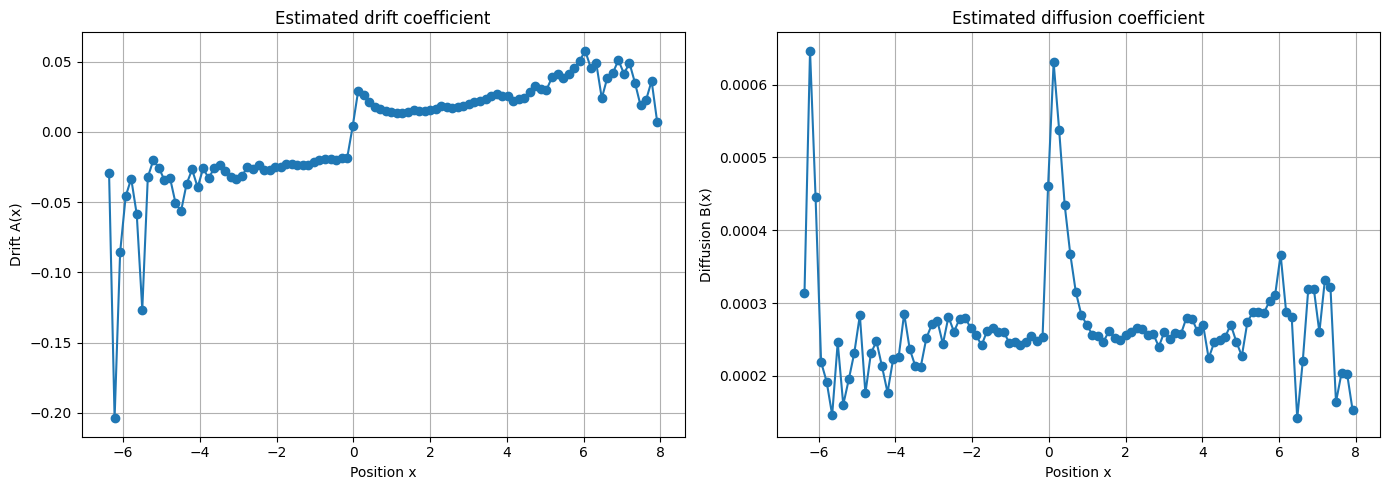

In [4]:
#Determiniing the coefficients of the Fokker Planck Equation
x_mid = x_all[:, :-1].flatten()                               #This takes all positions except the last time step.
dx = (x_all[:, 1:] - x_all[:, :-1]).flatten()                 #How far did the particle move in the next time step?

# Choose position bins
n_bins = 100
bins = np.linspace(x_mid.min(), x_mid.max(), n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

A = np.zeros(n_bins)       # drift
B = np.zeros(n_bins)       # diffusion
counts = np.zeros(n_bins)

for i in range(n_bins):
    mask = (x_mid >= bins[i]) & (x_mid < bins[i+1])
    counts[i] = np.sum(mask)

    if counts[i] > 0:
        A[i] = np.mean(dx[mask]) / dt
        B[i] = np.mean(dx[mask]**2) / dt
    else:
        A[i] = np.nan
        B[i] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(bin_centers, A, marker="o")
axes[0].set_xlabel("Position x")
axes[0].set_ylabel("Drift A(x)")
axes[0].set_title("Estimated drift coefficient")
axes[0].grid(True)

axes[1].plot(bin_centers, B, marker="o")
axes[1].set_xlabel("Position x")
axes[1].set_ylabel("Diffusion B(x)")
axes[1].set_title("Estimated diffusion coefficient")
axes[1].grid(True)

plt.tight_layout()
plt.show()

To capture the the functional form of the $A(x)$ and $B(x)$ we use the in-built function of scipy which uses a 1D Gaussian convolution to smooth the data or reducing noise.

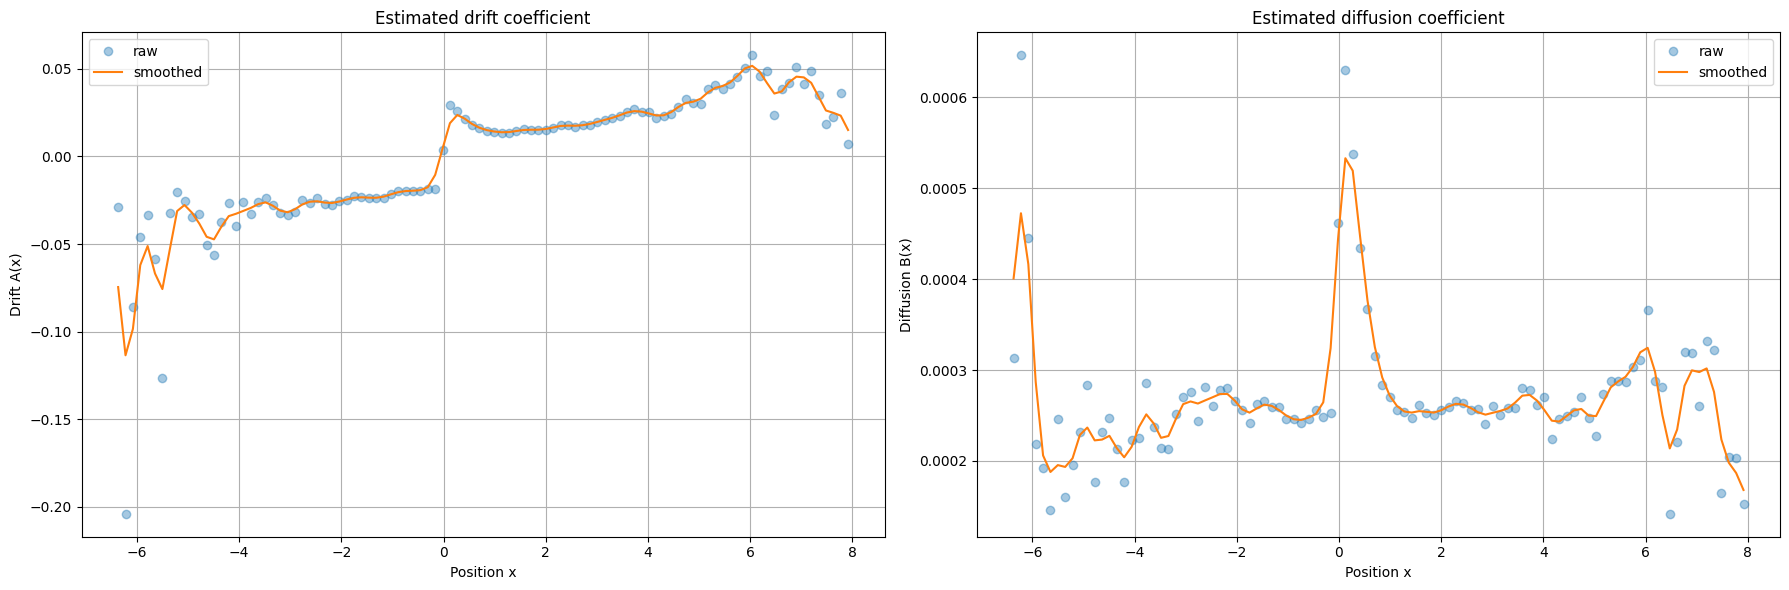

In [5]:
A_smooth = gaussian_filter1d(A, sigma=1, mode="nearest")
B_smooth = gaussian_filter1d(B, sigma=1, mode="nearest")


fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

# Drift subplot
axes[0].plot(bin_centers, A, "o", alpha=0.4, label="raw")
axes[0].plot(bin_centers, A_smooth, label="smoothed")
axes[0].set_xlabel("Position x")
axes[0].set_ylabel("Drift A(x)")
axes[0].set_title("Estimated drift coefficient")
axes[0].legend()
axes[0].grid(True)

# Diffusion subplot
axes[1].plot(bin_centers, B, "o", alpha=0.4, label="raw")
axes[1].plot(bin_centers, B_smooth, label="smoothed")
axes[1].set_xlabel("Position x")
axes[1].set_ylabel("Diffusion B(x)")
axes[1].set_title("Estimated diffusion coefficient")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

To visualise the probability density of particle positions at a specific time, i.e., $P(x,t=5000)$, we use the code below. We also calculate the area under the histogram, which is basically performing the following operation.

$$ \sum_i P(x_i ,t) \Delta x  = 1$$

It's important to note that in `np.histogram` we have selected density to be true, which converts the pure counts to probability density. As we can observe, the total area under the distribution is nearly one; this is a good sanity check.

Area under histogram = 0.9999999999999981


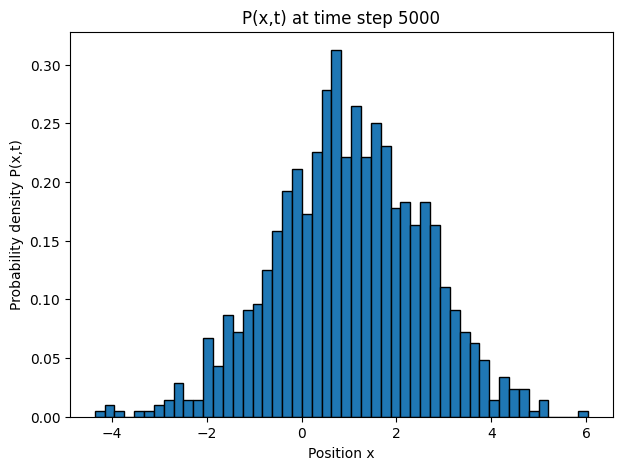

In [6]:
time_index = 5000                                            #The Time Stamp at which the probability is to be calculated
positions = x_all[:, time_index]
counts, bin_edges = np.histogram(
    positions,
    bins=50,
    density=True
)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

dx_bin = bin_edges[1] - bin_edges[0]
area = np.sum(counts * dx_bin)

print("Area under histogram =", area)

plt.figure(figsize=(7, 5))
plt.bar(
    bin_centers,
    counts,
    width=dx_bin,
    edgecolor="black"
)

plt.xlabel("Position x")
plt.ylabel("Probability density P(x,t)")
plt.title(f"P(x,t) at time step {time_index}")
plt.show()

Now, that we have the coefficeints of the Fokker-Planck Equation and also calcualte the probability of possible states for a given time. We can now also, compute the complete Fokker-Planck Equation and compare simulations with raw data.

In the code below we build the probability $P(x,t)$

In [7]:
#Building P(x,t)
n_runs, n_times = x_all.shape
bin_edges = np.linspace(x_all.min(), x_all.max(), n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
dx_bin = bin_edges[1] - bin_edges[0]

P = np.zeros((n_bins, n_times))

for ti in range(n_times):
    P[:, ti], _ = np.histogram(
        x_all[:, ti],
        bins=bin_edges,
        density=True
    )

Visualising $P(x,t)$ for a particular time step, we are basically computing the RHS of the Fokker-Planck Equation.
$$- \frac{\partial}{\partial x} \left[ A(x) P(x,t) \right] + \frac{1}{2}\frac{\partial^{2}}{\partial x^2} \left[ B(x) P(x,t) \right]$$

We first compute the terms inside the brackets and then take their gradients. Bringing everything together at the end.

In [8]:
#Choosing the time to evaluate the Fokker-Planck Equation
time_index = 1000

P_t = P[:, time_index]
P_t_smooth = gaussian_filter1d(P_t, sigma=1)

# Drift flux: A(x) P(x,t)
drift_flux = A_smooth * P_t_smooth

# Diffusion flux-like quantity: B(x) P(x,t)
diffusion_quantity = B_smooth * P_t_smooth

# First derivative: d/dx [A P]
d_drift_flux_dx = np.gradient(drift_flux, dx_bin)

# Second derivative: d²/dx² [B P]
d_diffusion_dx = np.gradient(diffusion_quantity, dx_bin)
d2_diffusion_dx2 = np.gradient(d_diffusion_dx, dx_bin)

# Fokker-Planck RHS
dPdt_fp = -d_drift_flux_dx + 0.5 * d2_diffusion_dx2

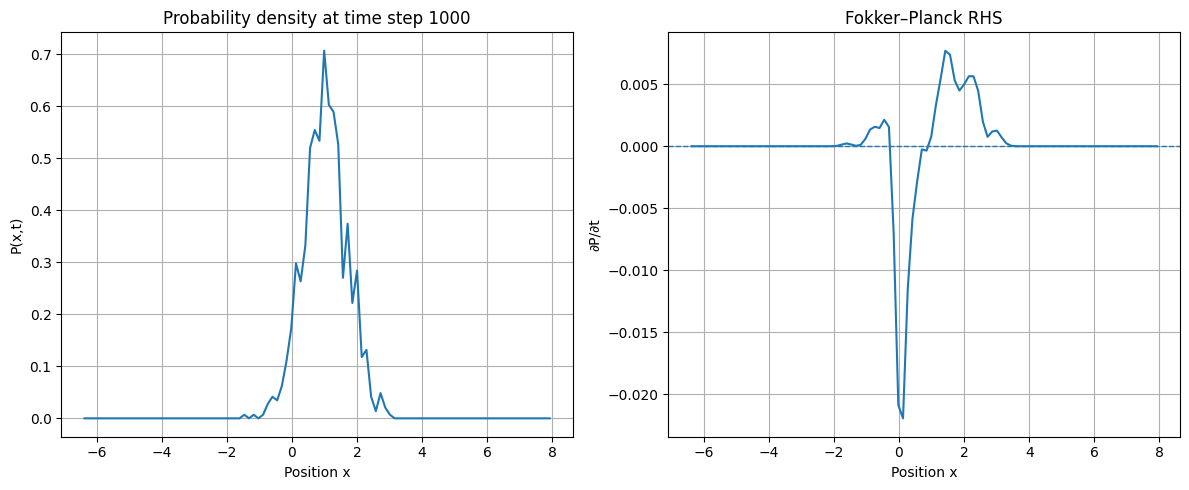

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

axes[0].plot(bin_centers, P_t)
axes[0].set_xlabel("Position x")
axes[0].set_ylabel("P(x,t)")
axes[0].set_title(f"Probability density at time step {time_index}")
axes[0].grid(True)

axes[1].plot(bin_centers, dPdt_fp)
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set_xlabel("Position x")
axes[1].set_ylabel("∂P/∂t")
axes[1].set_title("Fokker–Planck RHS")
axes[1].grid(True)

plt.tight_layout()
plt.show()

As we have probability data across time and position, we can calculate the actual values of $\frac{\partial P}{\partial t}$ using the Central Difference Method:

$$ \frac{\partial P}{\partial t} \approx \frac{P(x, t + h) - P(x,t - h)}{\Delta 2h}$$

In [10]:
b = 10
dPdt_data = (P[:, time_index + b] - P[:, time_index - b]) / (b * dt)

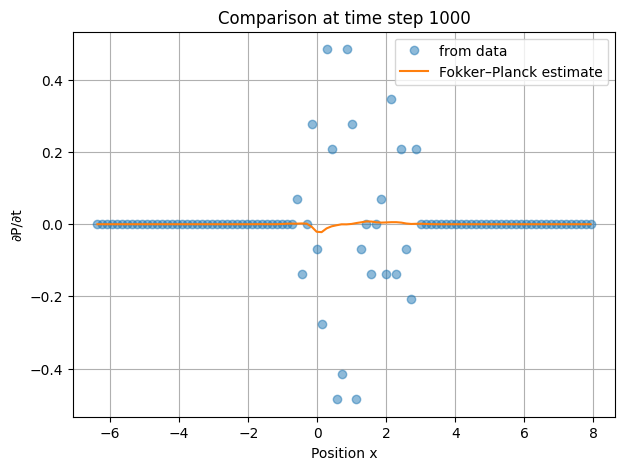

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(bin_centers, dPdt_data, "o", alpha=0.5, label="from data")
plt.plot(bin_centers, dPdt_fp, label="Fokker–Planck estimate")
plt.xlabel("Position x")
plt.ylabel("∂P/∂t")
plt.title(f"Comparison at time step {time_index}")
plt.legend()
plt.grid(True)
#plt.ylim(-0.02, 0.02)
plt.show()

In [12]:
dx_now = x_all[:, 1:-1] - x_all[:, :-2]
dx_next = x_all[:, 2:] - x_all[:, 1:-1]

In the above plot, the Fokker-Planck estimate data and the data don't match entirely because of the following reason:
1. The numerical derivatives, especially the second derivative, are very sensitive to small perturbations in $A(x)$, $B(x)$ and $P(x,t)$. So even if $A$, $B$ and $P$ look mildly noisy, the computed RHS can become very jagged. This is exactly what happens at $x=0$.
2. The drift and diffusion estimates in Eqn. (2) and (3) are small-time-limit formulas, and choosing $\Delta t$ that is not small enough can lead to these becoming finite-time estimates rather than true infinitesimal Fokker–Planck coefficients
3. The Fokker-Planck equation assumes particle trajectories are Markovian in $x$; if they are not, then it can cause the mismatch that we see.
4. The usual Fokker–Planck equation keeps only the first two Kramers–Moyal coefficients: drift and diffusion. That assumes the process is well-described by continuous diffusion. But if your particles sometimes make jumps, bursts, or rare large displacements, then higher-order Kramers–Moyal terms may matter.

In summary, we obtained various realisations of the stochastic process by changing the random seeds. We then used the information on particle positions over time to obtain $A(x)$ and $B(x)$ by measuring how much particles drift in a small time step $\Delta t$. Later, using the positions and time across all realisations, the complete probability distribution $P(x,t)$ was obtained. Finally, we compared the analytical value of $\frac{\partial P}{\partial t}$ with the values we got from the simulations.